In [81]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from keras.layers import *
from keras.models import Sequential
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
import shutil
import warnings
warnings.filterwarnings('ignore')

In [82]:
#read dataset ----> train, test
train_path = r'D:\Downloads\Image Preprocessing Project\breast_cancer_split_train_balanced\train'
test_path = r'D:\Downloads\Image Preprocessing Project\breast_cancer_split_train_balanced\test'
val_path = r'D:\Downloads\Image Preprocessing Project\breast_cancer_split_train_balanced\val'

In [83]:
image_classes = os.listdir(r'D:\Downloads\Image Preprocessing Project\breast_cancer_split_train_balanced\train')
print(image_classes)

['Cancer', 'Non-Cancer']


In [84]:
def plot_image(image_classes):
    plt.figure(figsize = (12,12))
    
    for i, category in enumerate(image_classes):
        image_path = train_path + '/' + category
        images_in_folder = os.listdir(image_path)
        
        first_image = images_in_folder[0]
        first_image_path = image_path + '/' + first_image
        
        img = image.load_img(first_image_path)
        img_array = image.img_to_array(img) / 255
        
        plt.subplot(1, 3, i + 1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')
    plt.show()

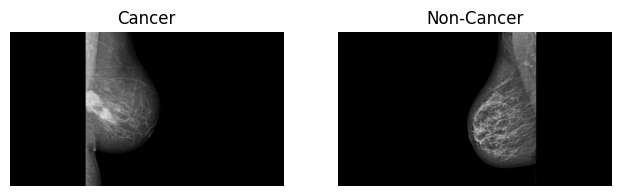

In [85]:
plot_image(image_classes)

In [86]:
#image preprocessing
data_generator = ImageDataGenerator(rescale = 1/255)

val_test_datagen_scratch = ImageDataGenerator(rescale=1/255)

In [87]:
#train data generator
train_data = data_generator.flow_from_directory(train_path,
                                                target_size = (224, 224),
                                                batch_size = 16 , 
                                                class_mode='categorical',
                                                shuffle=True
                                               )

Found 868 images belonging to 2 classes.


In [88]:
val_data = val_test_datagen_scratch.flow_from_directory(
    val_path,
    target_size=(224,244),
    batch_size= 16,
    class_mode='categorical',
    shuffle=False
)

Found 112 images belonging to 2 classes.


In [89]:
#test data generator
test_data = data_generator.flow_from_directory(test_path,
                                              target_size = (224, 224),
                                              batch_size = 16,
                                              class_mode='categorical',
                                              shuffle=False
                                              )

Found 112 images belonging to 2 classes.


In [90]:
# CNN Model
model = Sequential()

model.add(Input(shape=(224, 224, 3)))

model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,955,202 (49.42 MB)

 Trainable params: 12,955,202 (49.42 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,955,202 (49.42 MB)

 Trainable params: 12,955,202 (49.42 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:
#compile model
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy']
             )

In [93]:
#fit model 
model_history = model.fit(train_data,
                         epochs = 10,
                         validation_data = test_data)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7040 - loss: 0.5410 - val_accuracy: 0.9375 - val_loss: 0.1472
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9401 - loss: 0.1891 - val_accuracy: 0.9375 - val_loss: 0.1703
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9419 - loss: 0.2138 - val_accuracy: 0.9554 - val_loss: 0.1140
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9620 - loss: 0.1039 - val_accuracy: 0.9643 - val_loss: 0.0940
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9601 - loss: 0.1052 - val_accuracy: 0.9464 - val_loss: 0.1154
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9698 - loss: 0.1169 - val_accuracy: 0.9554 - val_loss: 0.0976
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9739 - loss: 0.0893 - val_accuracy: 0.9554 - val_loss: 0.0796
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9820 - loss: 0.0641 - val_accuracy: 0.9732 - val_loss:

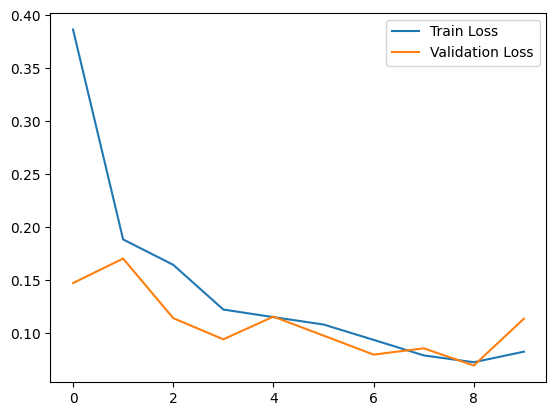

In [94]:
plt.plot(model_history.history['loss'], label = 'Train Loss')
plt.plot(model_history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

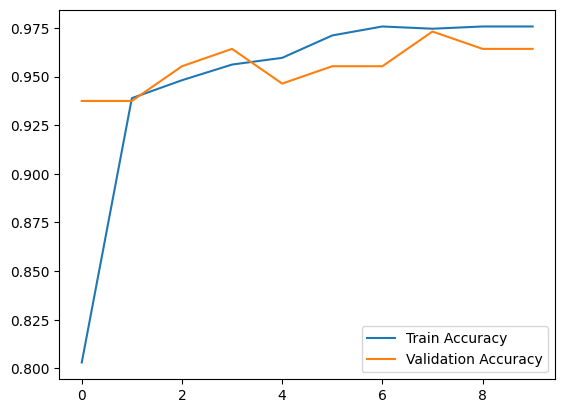

In [95]:
plt.plot(model_history.history['accuracy'], label = 'Train Accuracy')
plt.plot(model_history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend()
plt.show()

In [96]:
model.evaluate(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 570ms/step - accuracy: 0.9223 - loss: 0.2173


[0.11351598054170609, 0.9642857313156128]

In [97]:
model.save(r'D:\Downloads\Image Preprocessing Project\CNN_model.h5')

ResNet50

In [98]:
base_model = tf.keras.applications.ResNet50 (
    include_top=False,
    input_shape=(224, 224, 3),
    classes=2,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False


In [99]:
ResNet50_model = Sequential()

ResNet50_model.add(base_model)
ResNet50_model.add(Flatten())
ResNet50_model.add(Dense(512 , activation='relu'))
ResNet50_model.add(Dense(2 , activation='softmax'))


In [100]:
ResNet50_model.compile(optimizer = "adam",
                       loss = "categorical_crossentropy",
                       metrics = ["accuracy"])

In [101]:
ResNet50_model_history = ResNet50_model.fit(train_data , epochs = 10 , validation_data=test_data)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.5003 - loss: 6.7637 - val_accuracy: 0.1696 - val_loss: 1.2888
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.6007 - loss: 0.6453 - val_accuracy: 0.9107 - val_loss: 0.4573
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - accuracy: 0.7758 - loss: 0.5018 - val_accuracy: 0.6429 - val_loss: 0.6366
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.6616 - loss: 0.6016 - val_accuracy: 0.9375 - val_loss: 0.3087
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.8336 - loss: 0.4342 - val_accuracy: 0.9107 - val_loss: 0.4041
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.8224 - loss: 0.4337 - val_accuracy: 0.9107 - val_loss: 0.3184
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.8215 - loss: 0.4389 - val_accuracy: 0.8750 - val_loss: 0.4251
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.7707 - loss: 0.4749 - val_accuracy: 0.9286 - v

In [102]:
ResNet50_model.evaluate(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8975 - loss: 0.3155


[0.3354501724243164, 0.9107142686843872]

In [103]:
ResNet50_model.save(r'D:\Downloads\Image Preprocessing Project\ResNet50_model.h5')

DenseNet169

In [104]:
base_model = tf.keras.applications.DenseNet169 (
    include_top=False,
    input_shape=(224, 224, 3),
    classes=2,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False


In [105]:
DenseNet169_model = Sequential()

DenseNet169_model.add(base_model)
DenseNet169_model.add(Flatten())
DenseNet169_model.add(Dense(512 , activation='relu'))
DenseNet169_model.add(Dense(2 , activation='softmax'))


In [106]:
DenseNet169_model.compile(optimizer = "adam",
                       loss = "categorical_crossentropy",
                       metrics = ["accuracy"])

In [107]:
DenseNet169_model_history = DenseNet169_model.fit(train_data , epochs = 10 , validation_data=test_data)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.8282 - loss: 8.8448 - val_accuracy: 0.9554 - val_loss: 0.7778
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.9432 - loss: 0.4794 - val_accuracy: 0.9643 - val_loss: 0.4269
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9774 - loss: 0.2890 - val_accuracy: 0.9107 - val_loss: 0.5112
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.9920 - loss: 0.0260 - val_accuracy: 0.9643 - val_loss: 0.2252
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.9773 - loss: 0.1317 - val_accuracy: 0.9375 - val_loss: 0.7617
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.9806 - loss: 0.1005 - val_accuracy: 0.9732 - val_loss: 0.2530
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.9818 - loss: 0.1087 - val_accuracy: 0.9375 - val_loss: 0.7528
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.9927 - loss: 0.0302 - val_accuracy: 0.9643 - v

In [108]:
DenseNet169_model.save(r'D:\Downloads\Image Preprocessing Project\DenseNet169_model.h5')

In [109]:
class_map = dict([value, key] for key, value in train_data.class_indices.items())
class_map

{0: 'Cancer', 1: 'Non-Cancer'}

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


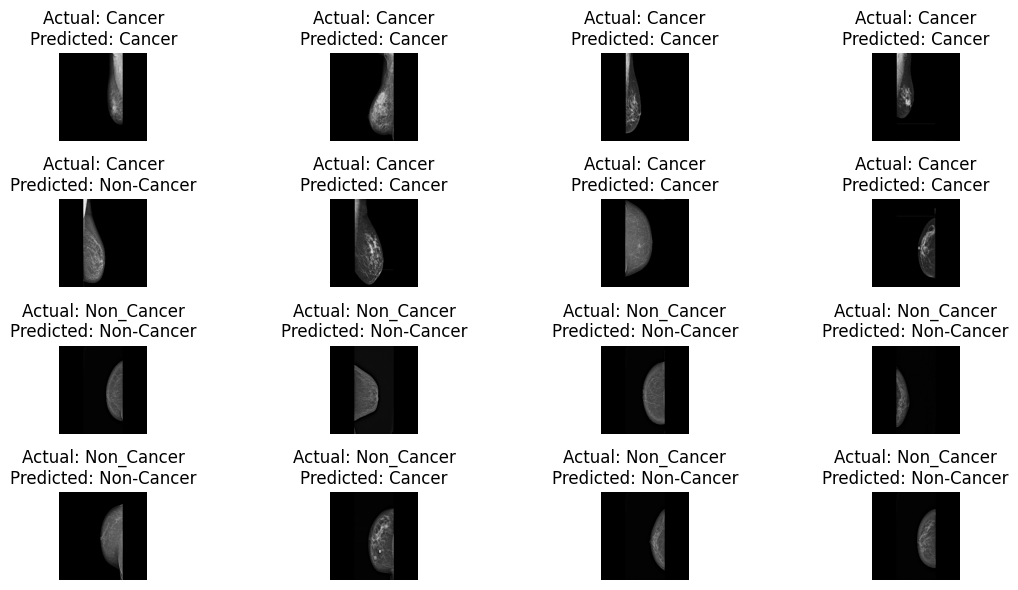

In [110]:
def prediction(ax, test_image, actual_label):
    # Load & preprocess image
    testing_img = image.load_img(test_image, target_size=(224, 224))
    test_img_array = image.img_to_array(testing_img) / 255
    
    test_img_input = test_img_array.reshape(1, test_img_array.shape[0],
                                           test_img_array.shape[1],
                                           test_img_array.shape[2])
    
    # Make prediction
    predicted_class = np.argmax(DenseNet169_model.predict(test_img_input))
    predicted_img = class_map[predicted_class]
    
    # Display the image on the provided axes (ax)
    ax.imshow(test_img_array)
    ax.set_title(f'Actual: {actual_label}\nPredicted: {predicted_img}')
    ax.axis('off')

def predict_random_images():
    # Paths to the classes
    Cancer_path = os.path.join(test_path, 'Cancer')
    Non_Canceer_path = os.path.join(test_path, 'Non-Cancer')
    
    # List of all images in the 'cancer' and 'non_cancer' folders
    Cancer_images = os.listdir(Cancer_path)
    Non_Cancer_images = os.listdir(Non_Canceer_path)
    
    # Randomly choose 4 images from each class
    chosen_cancer_images = random.sample(Cancer_images, 8)
    chosen_non_cancer_images = random.sample(Non_Cancer_images, 8)
    
    # Combine all chosen images
    all_chosen_images = chosen_cancer_images + chosen_non_cancer_images
    
    # Create subplots
    fig, axes = plt.subplots(4, 4, figsize=(12, 6)) 
    axes = axes.ravel()  # Flatten axes array for easier iteration
    
    # Predict for each chosen image and display in the subplot
    for i, image_name in enumerate(all_chosen_images):
        if image_name in chosen_cancer_images:
            actual_label = 'Cancer'
            image_path = os.path.join(Cancer_path, image_name)
        else:
            actual_label = 'Non_Cancer'
            image_path = os.path.join(Non_Canceer_path, image_name)
        
        # Call the prediction function to display the image in the corresponding subplot
        prediction(axes[i], image_path, actual_label)
    
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

# Call the function to predict random 8 images
predict_random_images()


In [111]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [112]:
def plot_training_curves(history, model_name):
    # Loss Curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy Curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [113]:
def evaluate_classification_model(model, test_generator, model_name):
    test_generator.reset()

    # Predictions
    y_prob = model.predict(test_generator)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes

    # Class names ordered by index
    class_names = [name for name, index in sorted(
        test_generator.class_indices.items(),
        key=lambda x: x[1]
    )]

    print(f"\n================ {model_name} Evaluation ================\n")

    # Choose Cancer as positive class if it exists
    positive_class_index = test_generator.class_indices.get('Cancer', 1)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        pos_label=positive_class_index,
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        pos_label=positive_class_index,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=positive_class_index,
        zero_division=0
    )

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

    # ROC / AUC Curve
    if len(class_names) == 2:
        y_true_binary = (y_true == positive_class_index).astype(int)
        y_score = y_prob[:, positive_class_index]

        fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.title(f'{model_name} - ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        print(f"ROC-AUC   : {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

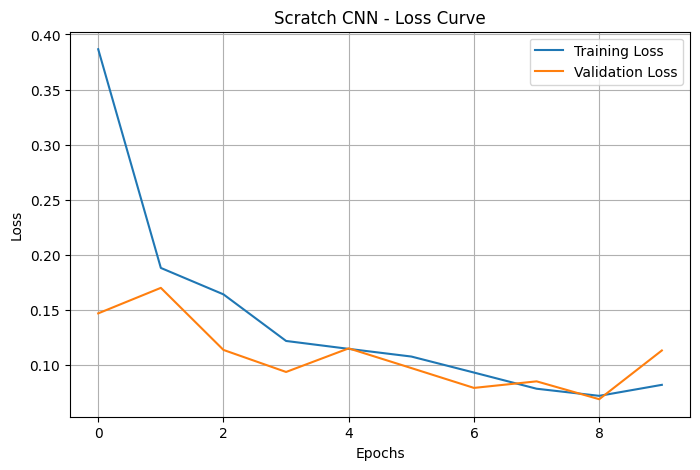

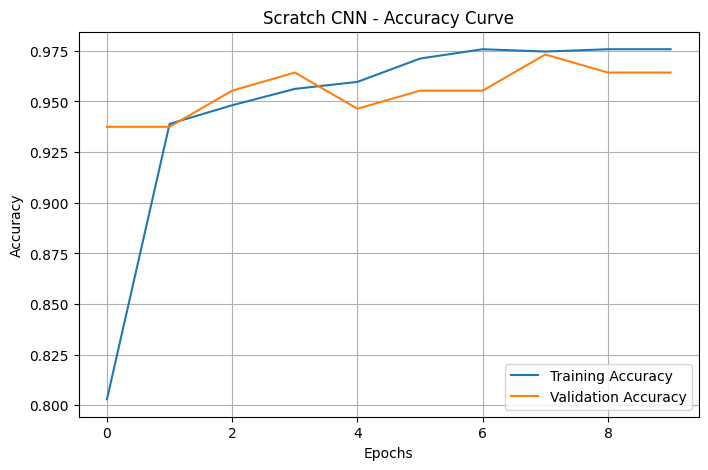

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 369ms/step

================ Scratch CNN Evaluation ================

Accuracy  : 0.9643
Precision : 1.0000
Recall    : 0.7895
F1-Score  : 0.8824

Classification Report:

              precision    recall  f1-score   support

      Cancer       1.00      0.79      0.88        19
  Non-Cancer       0.96      1.00      0.98        93

    accuracy                           0.96       112
   macro avg       0.98      0.89      0.93       112
weighted avg       0.97      0.96      0.96       112



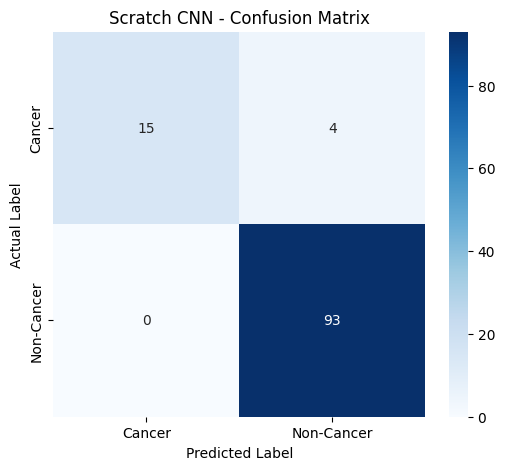

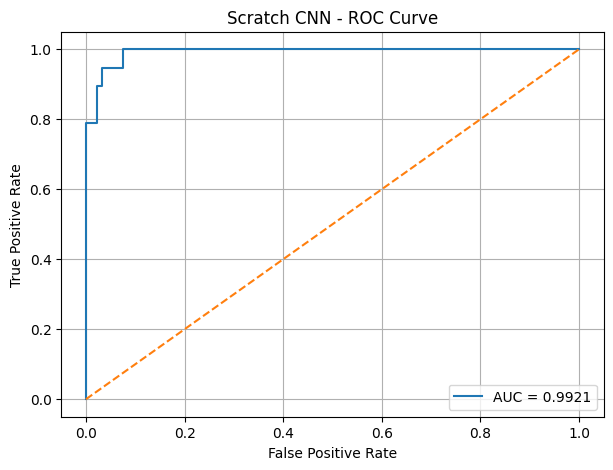

ROC-AUC   : 0.9921


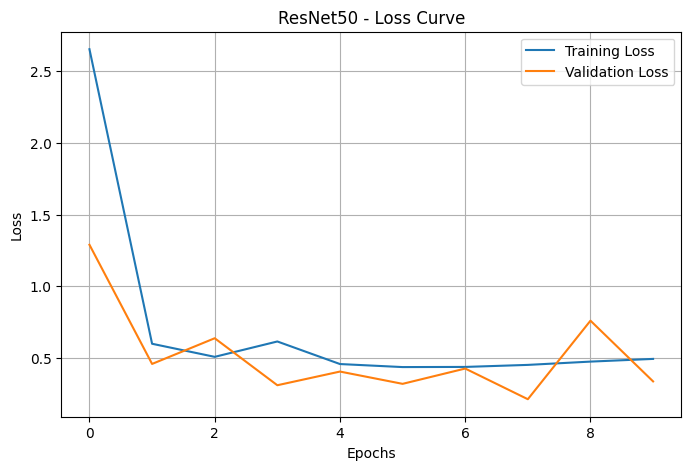

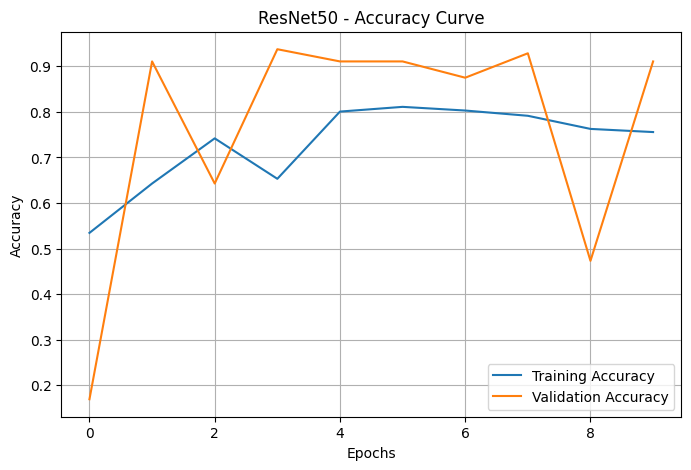

7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

================ ResNet50 Evaluation ================

Accuracy  : 0.9107
Precision : 0.6957
Recall    : 0.8421
F1-Score  : 0.7619

Classification Report:

              precision    recall  f1-score   support

      Cancer       0.70      0.84      0.76        19
  Non-Cancer       0.97      0.92      0.95        93

    accuracy                           0.91       112
   macro avg       0.83      0.88      0.85       112
weighted avg       0.92      0.91      0.91       112



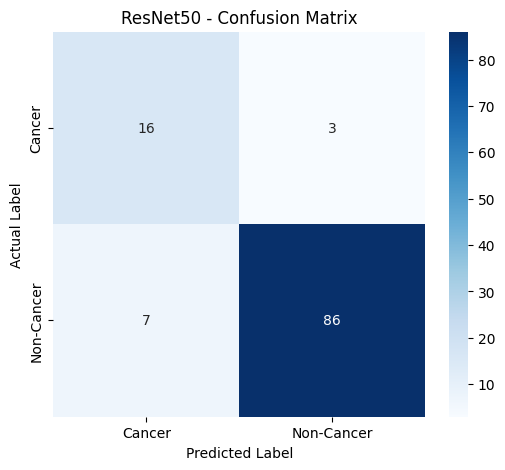

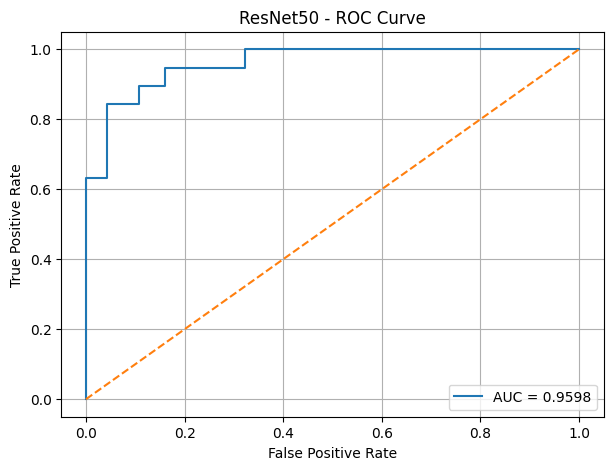

ROC-AUC   : 0.9598


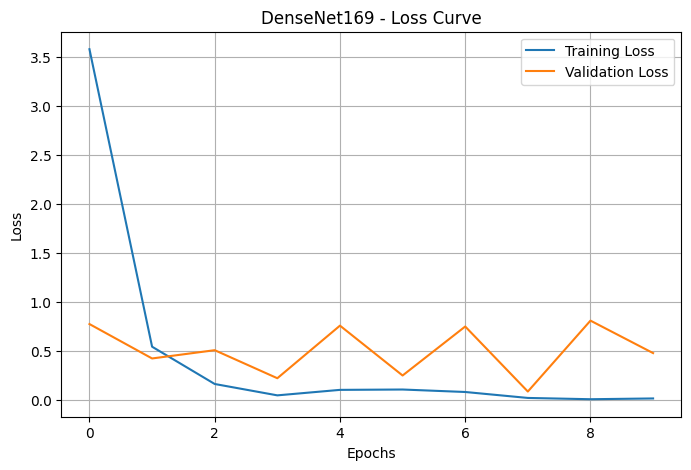

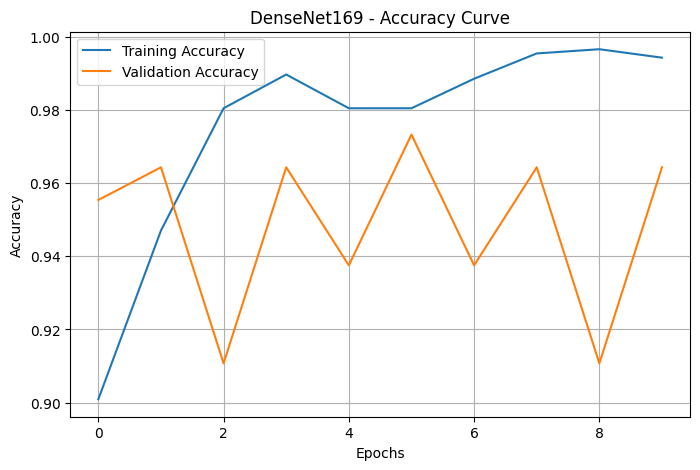

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step

================ DenseNet169 Evaluation ================

Accuracy  : 0.9643
Precision : 0.9412
Recall    : 0.8421
F1-Score  : 0.8889

Classification Report:

              precision    recall  f1-score   support

      Cancer       0.94      0.84      0.89        19
  Non-Cancer       0.97      0.99      0.98        93

    accuracy                           0.96       112
   macro avg       0.95      0.92      0.93       112
weighted avg       0.96      0.96      0.96       112



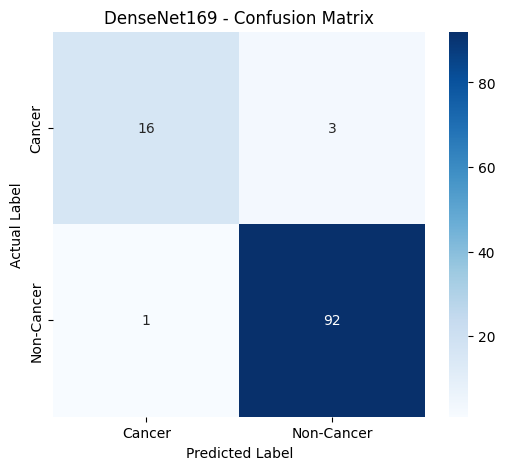

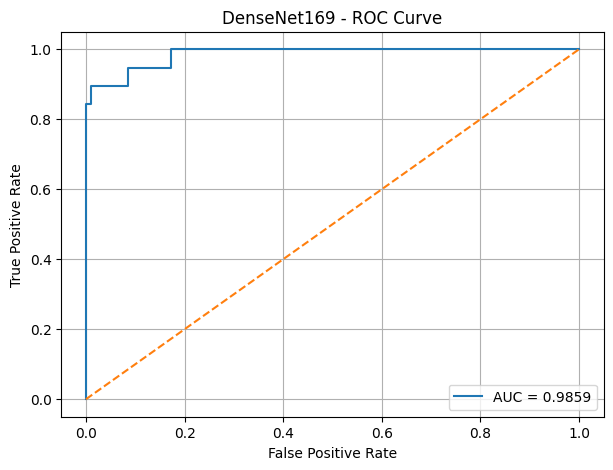

ROC-AUC   : 0.9859


In [114]:
results = []

# Scratch CNN
plot_training_curves(model_history, "Scratch CNN")
results.append(evaluate_classification_model(model, test_data, "Scratch CNN"))

# ResNet50
plot_training_curves(ResNet50_model_history, "ResNet50")
results.append(evaluate_classification_model(ResNet50_model, test_data, "ResNet50"))

# DenseNet169
plot_training_curves(DenseNet169_model_history, "DenseNet169")
results.append(evaluate_classification_model(DenseNet169_model, test_data, "DenseNet169"))

In [115]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Scratch CNN,0.964286,1.000000,0.789474,0.882353
1,ResNet50,0.910714,0.695652,0.842105,0.761905
2,DenseNet169,0.964286,0.941176,0.842105,0.888889


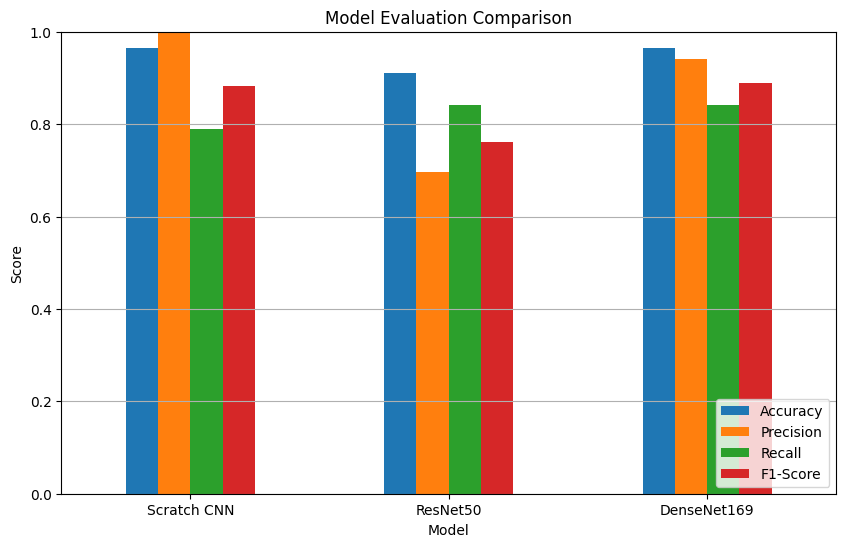

In [116]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Evaluation Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.show()